## Dataset
The data comes from a subset of The National Centers for Environmental Information (NCEI) [Global Historical Climatology Network daily (GHCNd)](https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily) (GHCN-Daily). The GHCN-Daily is comprised of daily climate records from thousands of land surface stations across the globe. we will use data from the Ann Arbor Michigan location.
* **id** : station identification code
* **date** : date in YYYY-MM-DD format
* **element** : indicator of element type
    * TMAX : Maximum temperature (tenths of degrees C)
    * TMIN : Minimum temperature (tenths of degrees C)
* **value** : data value for element (tenths of degrees C)

## Step 0: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from calendar import month_abbr

## Step 1: Data Loading

In [2]:
df = pd.read_csv('fb441e62df2d58994928907a91895ec62c2c42e6cd075c2700843b89.csv')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165085 entries, 0 to 165084
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          165085 non-null  object
 1   Date        165085 non-null  object
 2   Element     165085 non-null  object
 3   Data_Value  165085 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 5.0+ MB
None


,ID,Date,Element,Data_Value
0,USW00094889,2014-11-12,TMAX,22
1,USC00208972,2009-04-29,TMIN,56
2,USC00200032,2008-05-26,TMAX,278
3,USC00205563,2005-11-11,TMAX,139
4,USC00200230,2014-02-27,TMAX,-106


## Step 2: Data Preprocessing and Cleaning

In [3]:
# Convert Date data type to Datetime
df['Date'] = pd.to_datetime(df['Date'])

# Scale Data_Value by dividing by 10
df['Data_Value'] /= 10

# Separate max from min
df_max = df[df['Element'] == 'TMAX']
df_min = df[df['Element'] == 'TMIN']

# Remove leap day and calculate the daily max and min
daily_max = df_max[~((df_max['Date'].dt.month == 2) & (df_max['Date'].dt.day == 29))].groupby('Date')['Data_Value'].max().reset_index()
daily_min = df_min[~((df_min['Date'].dt.month == 2) & (df_min['Date'].dt.day == 29))].groupby('Date')['Data_Value'].min().reset_index()

## Step 3: Calculating Historical and Record Temperatures

In [4]:
# Formatting Dates for Yearly Comparison
daily_max['Month_Day'] = daily_max['Date'].dt.strftime('%m-%d')
daily_min['Month_Day'] = daily_min['Date'].dt.strftime('%m-%d')

# Set 2015 cutoff date
cutoff_date = '2015-01-01'

# Get historical records (2005-2014)
daily_max_before_2015 = daily_max[daily_max['Date'] < cutoff_date].groupby('Month_Day')['Data_Value'].max().reset_index()
daily_min_before_2015 = daily_min[daily_min['Date'] < cutoff_date].groupby('Month_Day')['Data_Value'].min().reset_index()

# Get daily records specifically for 2015
daily_max_2015 = daily_max[daily_max['Date'] >= cutoff_date].groupby('Month_Day')['Data_Value'].max().reset_index()
daily_min_2015 = daily_min[daily_min['Date'] >= cutoff_date].groupby('Month_Day')['Data_Value'].min().reset_index()

## Step 4: Data Visualization

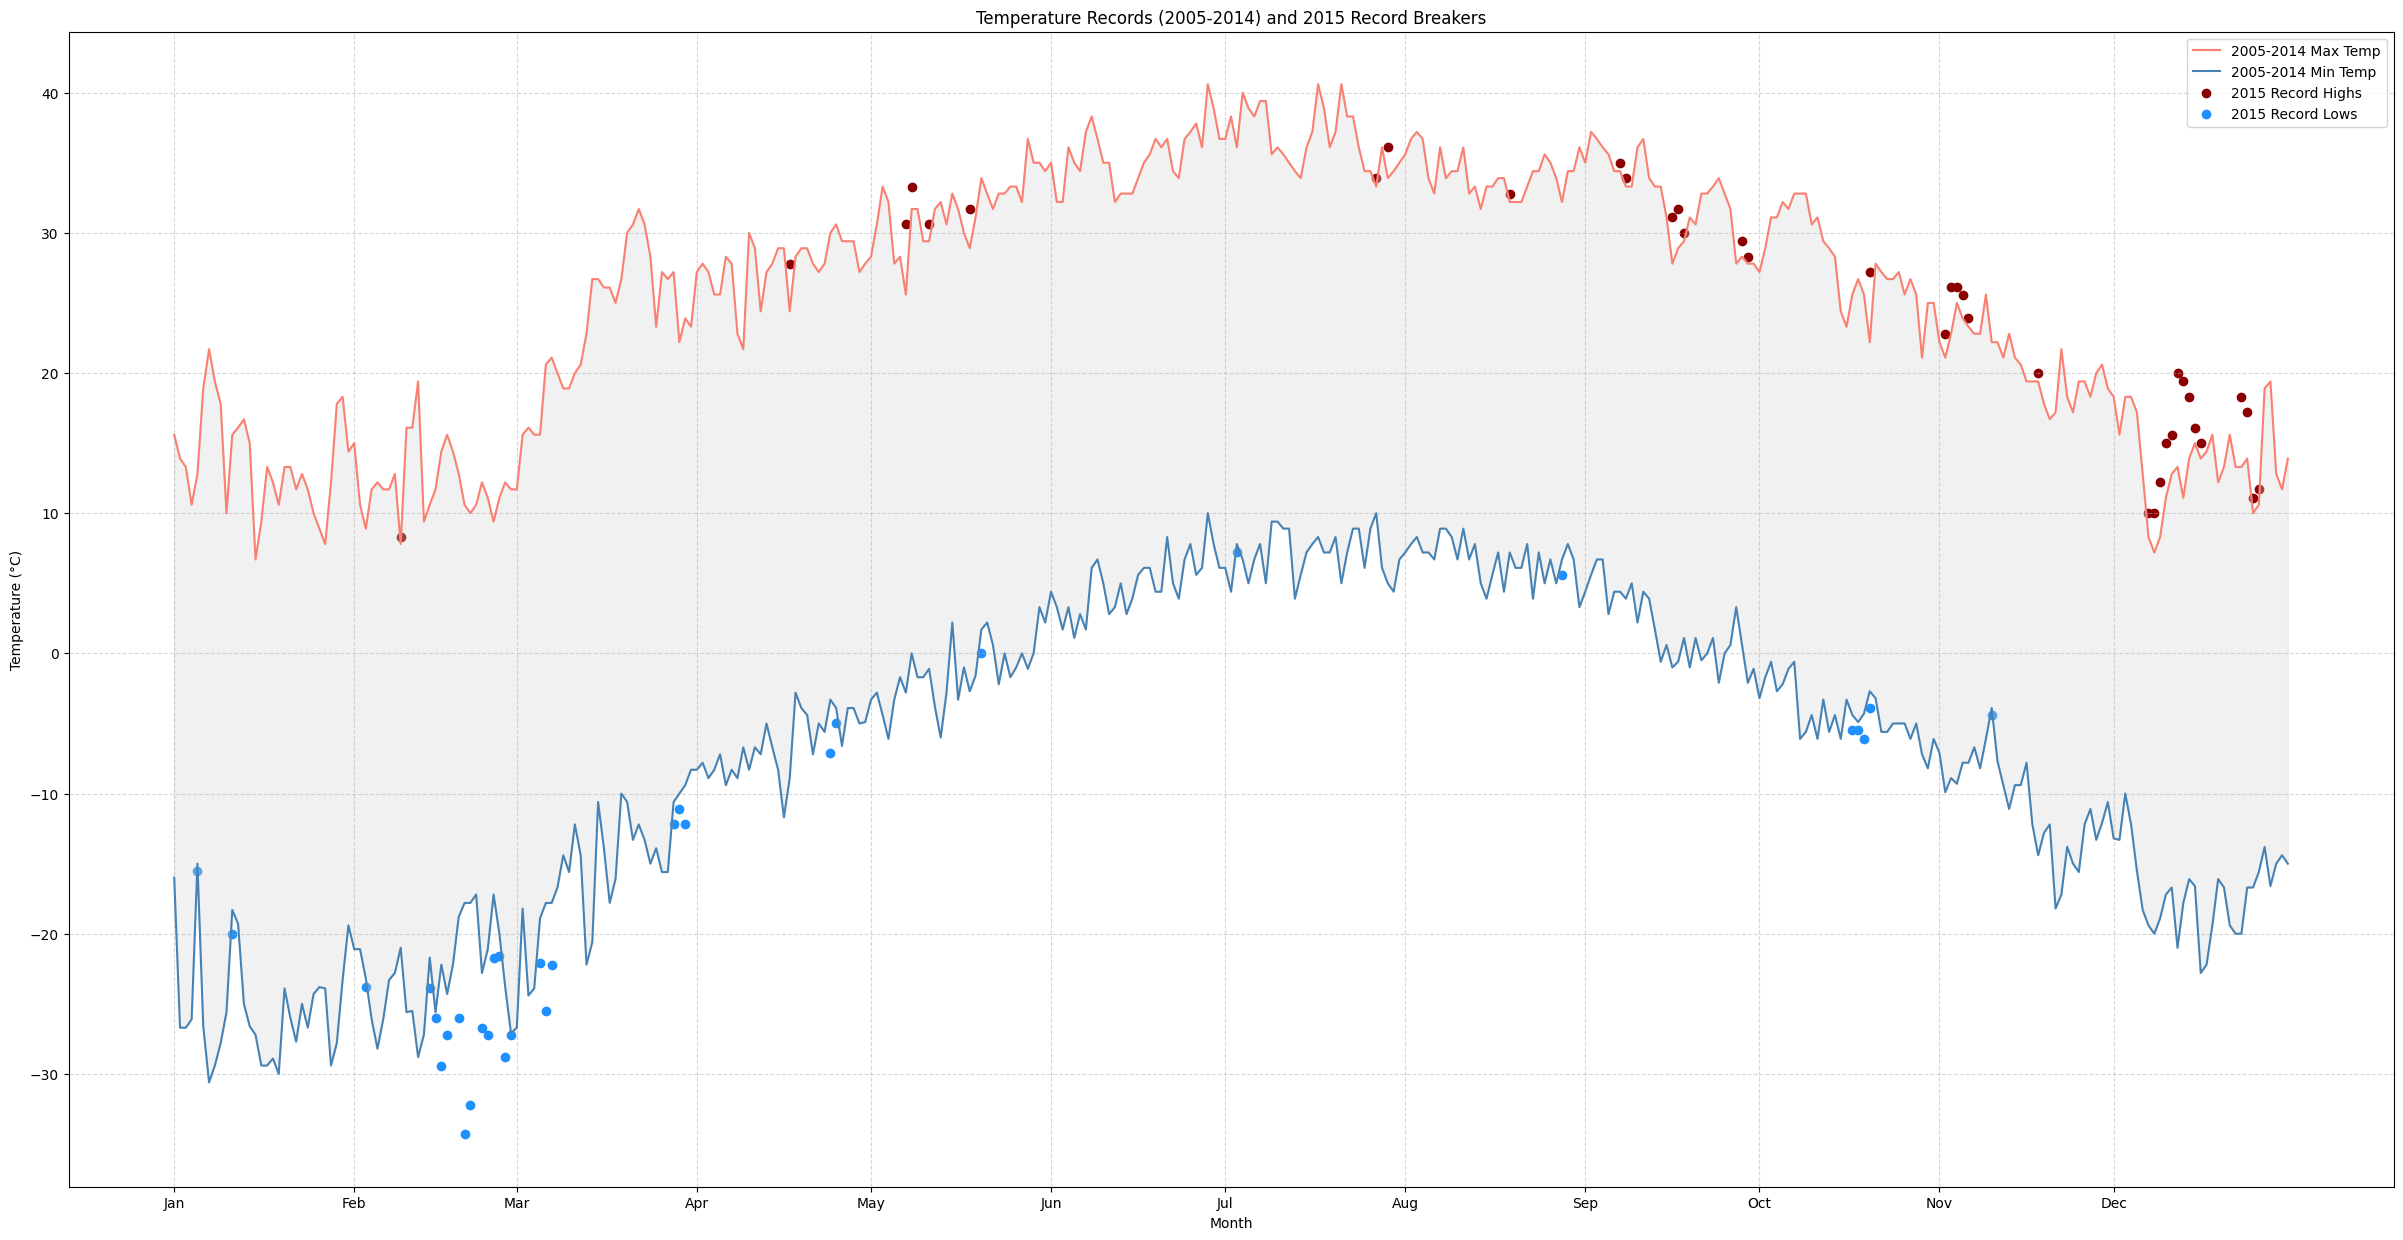

In [5]:
plt.figure(figsize=(30, 15))

# Plot max and min temperatures for 2005-2014
plt.plot(daily_max_before_2015['Data_Value'], color='salmon', label='2005-2014 Max Temp')
plt.plot(daily_min_before_2015['Data_Value'], color='steelblue', label='2005-2014 Min Temp')

# Scatter plot for 2015 record-breaking temperatures
plt.scatter(
    x=daily_max_2015.index[daily_max_2015['Data_Value'] > daily_max_before_2015['Data_Value']],
    y=daily_max_2015['Data_Value'][daily_max_2015['Data_Value'] > daily_max_before_2015['Data_Value']],
    color='darkred', label='2015 Record Highs'
)
plt.scatter(
    x=daily_min_2015.index[daily_min_2015['Data_Value'] < daily_min_before_2015['Data_Value']],
    y=daily_min_2015['Data_Value'][daily_min_2015['Data_Value'] < daily_min_before_2015['Data_Value']],
    color='dodgerblue', label='2015 Record Lows'
)

# Fill area between max and min temperatures
plt.fill_between(range(365), daily_min_before_2015['Data_Value'], daily_max_before_2015['Data_Value'], color='lightgrey', alpha=0.3)

# Add labels, legend, and month ticks
month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
plt.legend()
plt.xticks(month_starts, month_abbr[1:])
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Records (2005-2014) and 2015 Record Breakers")
plt.grid(True, linestyle='--', alpha=0.5)